# Employee Feedback Analysis Using BERT (Pretrained Model)



## Background 

XYZ Company conducted its Annual Performance Appraisal process as part of its routine HR practices. Employees were asked to provide feedback on the overall process and the questions used to assess their performance levels.

## Objective
The objective of this study is to analyze employee feedback to understand their overall perception of the appraisal system and identify areas for improvement.

For this purpose, BERT (Bidirectional Encoder Representations from Transformers), a pretrained language model, is used. BERT is trained on large-scale text datasets such as Wikipedia and BookCorpus. During pretraining, it learns language representations using:

- Masked Language Modeling (MLM) – predicting masked words in a sentence

- Next Sentence Prediction (NSP) – understanding relationships between sentence pairs

These tasks help BERT capture deep contextual meaning. The pretrained model is then fine-tuned for specific tasks such as sentiment classification of employee feedback.



### Import Libraries

In [4]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import re

**from transformers import pipeline** - imports the ready-to-use pipeline API from the Hugging Face Transformers library to quickly run pretrained NLP tasks like sentiment analysis, translation, etc. in one line.

### Load Data

In [5]:
# Read the text file (each line = one review)
with open("HR Appraisal process.txt", "r", encoding="utf-8") as file:
    lines = file.readlines()

# Convert to DataFrame
data = pd.DataFrame(lines, columns=['Emp_Feedback'])

# Clean the text: remove punctuation and special characters
data['Emp_Feedback'] = data['Emp_Feedback'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', str(x)))

data.head()

,Emp_Feedback
0,The process was not transparent\n
1,There is a lot of scope to improve the process...
2,Happy with the process but salary increment in...
3,Many questions were very subjective Very diffi...
4,Questions could have been specific to function...


### Data Preprocessing

Traditional NLP methods require heavy preprocessing such as lowercasing, stopword removal, stemming, and feature engineering (like TF-IDF or Bag of Words) because they cannot understand raw text directly. 

In contrast, BERT requires only minimal preprocessing, such as removing null values and extra spaces.

This is because BERT uses a tokenizer and contextual embeddings to understand the meaning of words based on their context.

In [6]:
data['Emp_Feedback'] = data['Emp_Feedback'].str.strip()

### Model Initialization (BERT)

Builds a complete NLP workflow inside one object—loading a pretrained BERT model, its tokenizer, and the logic to preprocess text → run prediction → return sentiment labels—using the Hugging Face Transformers pipeline API.

In [7]:
#initializes a pre-trained BERT model for sentiment analysis using the Hugging Face pipeline. 
bert_model = pipeline("sentiment-analysis") 

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

### Sentiment Analysis using BERT

In [8]:
data['bert_result'] = data['Emp_Feedback'].apply(lambda x: bert_model(str(x))[0])
data['bert_sentiment'] = data['bert_result'].apply(lambda x: x['label'])
data['bert_score'] = data['bert_result'].apply(lambda x: x['score'])

### Output Interpretation

Each employee feedback is analyzed using BERT to predict its sentiment as **POSITIVE or NEGATIVE** along with a confidence score (`bert_score`). The `bert_result` contains the raw model output, helping us understand both the predicted label and how confident the model is.


In [9]:
data.head(20)

,Emp_Feedback,bert_result,bert_sentiment,bert_score
0,The process was not transparent,"{'label': 'NEGATIVE', 'score': 0.9994736313819...",NEGATIVE,0.999474
1,There is a lot of scope to improve the process...,"{'label': 'POSITIVE', 'score': 0.9703544974327...",POSITIVE,0.970354
2,Happy with the process but salary increment in...,"{'label': 'NEGATIVE', 'score': 0.9984462857246...",NEGATIVE,0.998446
3,Many questions were very subjective Very diffi...,"{'label': 'NEGATIVE', 'score': 0.9992345571517...",NEGATIVE,0.999235
4,Questions could have been specific to function...,"{'label': 'NEGATIVE', 'score': 0.9981536269187...",NEGATIVE,0.998154
5,More research is required to come out with bet...,"{'label': 'NEGATIVE', 'score': 0.998149037361145}",NEGATIVE,0.998149
6,Very happy with the process adopted Fair and t...,"{'label': 'POSITIVE', 'score': 0.9997867941856...",POSITIVE,0.999787
7,Salary increment is extremely low as compared ...,"{'label': 'NEGATIVE', 'score': 0.9996881484985...",NEGATIVE,0.999688
8,Not happy with rating methodology Very subject...,"{'label': 'NEGATIVE', 'score': 0.9996459484100...",NEGATIVE,0.999646
9,Excellent effort by HR team Very fair process,"{'label': 'POSITIVE', 'score': 0.9998237490653...",POSITIVE,0.999824


### Example interpretations:

* **Row 0:**
  Predicted as *NEGATIVE*, correctly identifying the dissatisfaction in the review with high confidence.

* **Row 1:**
  Predicted as *POSITIVE*, but this is incorrect. The model likely misinterprets constructive or neutral phrasing as positive sentiment, leading to a confident misclassification.

* **Row 6:**
  Predicted as *POSITIVE*, correctly capturing the strong positive sentiment expressed in the review.








In [10]:
data['bert_sentiment'].value_counts()

bert_sentiment
NEGATIVE    28
POSITIVE    20
Name: count, dtype: int64

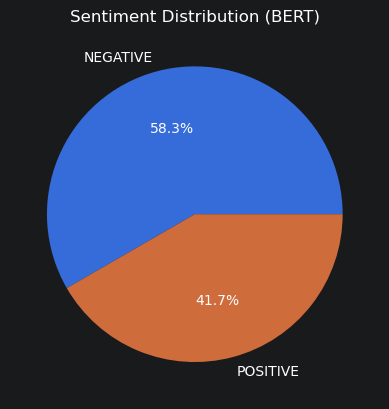

In [11]:
sentiment_counts = data['bert_sentiment'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Sentiment Distribution (BERT)")
plt.show()